# t-SNE and UMAP

This local adaptation demonstrates two nonlinear dimensionality-reduction techniques on scikit-learn's handwritten-digits dataset. The notebook uses deterministic settings so it can be rerun offline.

The current Coursera lab is hosted in the course runtime; this executable local version is provided because an exact public notebook artifact was not available.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import umap.umap_ as umap
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [2]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
print(f'X shape: {X.shape}; classes: {np.unique(y).size}')


X shape: (1797, 64); classes: 10


## t-SNE

t-SNE preserves local neighborhoods. Its coordinates are not directly interpretable as features, and changing the random seed can change the orientation of the map.


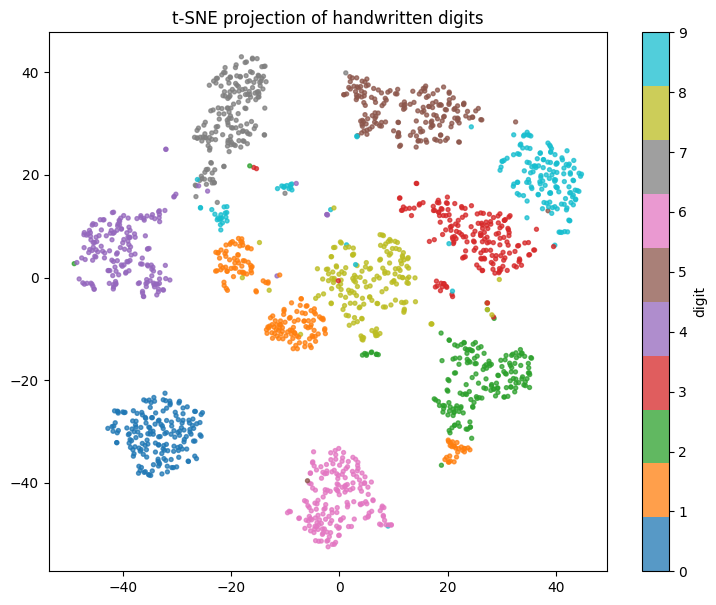

In [3]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
plt.title('t-SNE projection of handwritten digits')
plt.colorbar(label='digit')
plt.show()


## UMAP

UMAP is another neighborhood-preserving embedding. `n_neighbors` controls the local/global balance, while `min_dist` controls how tightly points may pack in the embedding.


C:\Users\Khoai\RMIT\Machine_Learning\Python For Machine Learning IBM\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Khoai\RMIT\Machine_Learning\Python For Machine Learning IBM\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


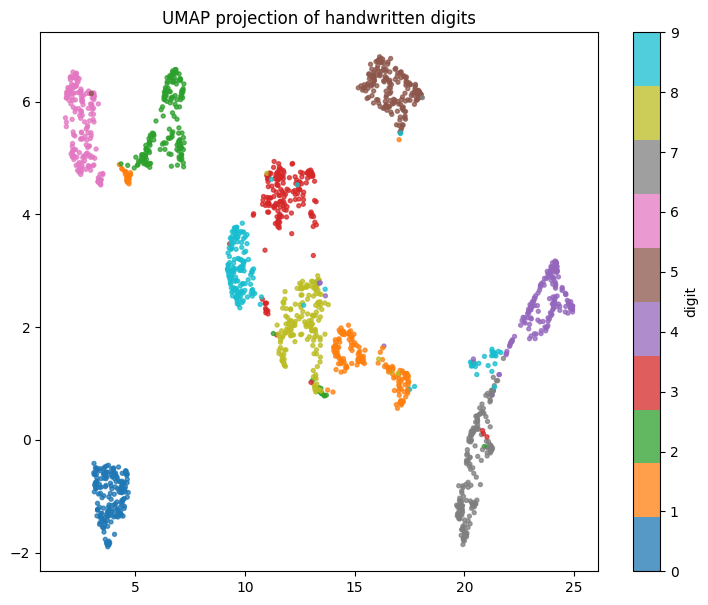

In [4]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)
plt.figure(figsize=(9, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
plt.title('UMAP projection of handwritten digits')
plt.colorbar(label='digit')
plt.show()
